This tutorial's problems are concerned with the Bayesian Statistics.

In [20]:
import numpy as np
import scipy as scp
import scipy.stats as stats
import matplotlib.pyplot as plt
import math
from astropy.visualization.hist import hist as fancyhist


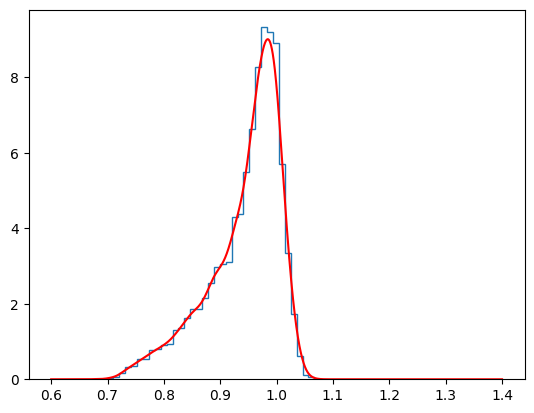

In [ ]:
#sample number
N  = 10000
#first define the mass destribution 
mu = 1
std_div = 0.02
#now define the spin destribution
spin_boundaries = [0,1]
#samples
M= np.random.normal(mu, std_div, N)
spin = np.random.uniform(spin_boundaries[0], spin_boundaries[1], N)
# now, define the M_irr function
M_irr = np.vectorize(lambda spin, M: M*((1+(1-spin**2)**0.5)/2)**0.5)

sample = M_irr(spin, M)
#for the histgoram we are going to use the automatically generated bins(Important idea)
_ = fancyhist(sample, bins="scott", histtype="step",density=True)
#now let's add some KDE predictions
x_range = np.linspace(mu-0.4,mu+0.4,5000)
kde = stats.gaussian_kde(sample)
kde_prediction = kde(x_range)                    
plt.plot(x_range,kde_prediction,color="red")

plt.show()


Now, we have to perform the Kolmogorov-Smirnov tests on the predefined function f:


$f = \frac{M_{irr}}{M} = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$

To do this we first have to compute the pdf of this function, so that we then could find it's CDF and perform the KS test 

In [ ]:
#now we have to perform the KS test 
#first initialize the pdf's
#this gives a numerical estimate for the similarity of distributions
stats.kstest(sample, spin).statistic

0.7607

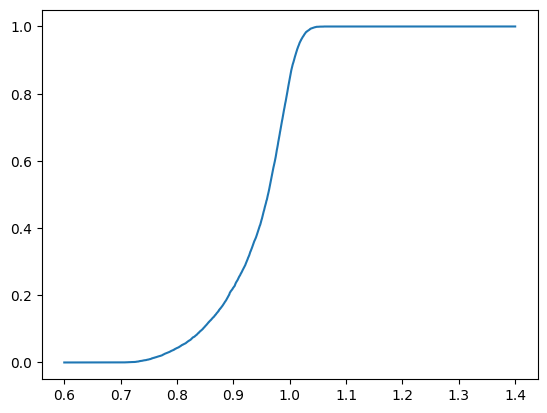

In [ ]:
#empirical cdf code(this is unrelated to the assignment I just write this for myself ahaaa)
def empir_cdf(sample, grid):
    size = len(sample)
    cdf  = np.zeros(len(grid))
    for i,x in enumerate(grid):
        cdf[i] = len(sample[sample<x])/size
    return cdf
cdf_y = empir_cdf(sample,x_range)
plt.plot(x_range, cdf_y)
plt.show()
#amazing, genius idea I like how it works(this is just an appendix)